C:\Users\86185\anaconda3\envs\sklearn\lib\site-packages\ipykernel_launcher.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if __name__ == "__main__":


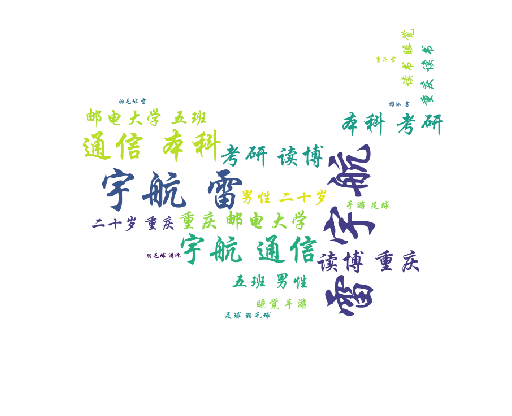

In [9]:
## 实例一
import jieba
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import imageio
wf = 'per_info.txt'
word_content = open(wf,'r',encoding='utf-8').read().replace('\n','')#读取文件内容
img_file= 'china.jpg'#设置背景图片
mask_img= imageio.imread(img_file)#解析背景图片
word_cut= jieba.cut(word_content)#进行分词
word_cut_join = " ".join(word_cut)#把分词用空格连接起来
#设置词云参数
wc = WordCloud(
    font_path = 'STXINGKA.TTF',#设置字体
    max_words = 300,#允许最大词汇量
    max_font_size= 100,#设置最大号字体
    mask = mask_img,#设置使用的背景图片，这个参数不为空时，width和height会被忽略
    background_color = 'white')#设置输出图片的背景色
wc.generate(word_cut_join)#生成词云
plt.imshow(wc)#用于显示图片
plt.axis('off')#去掉坐标轴
plt.savefig('结果图.LYH.png')
plt.show()

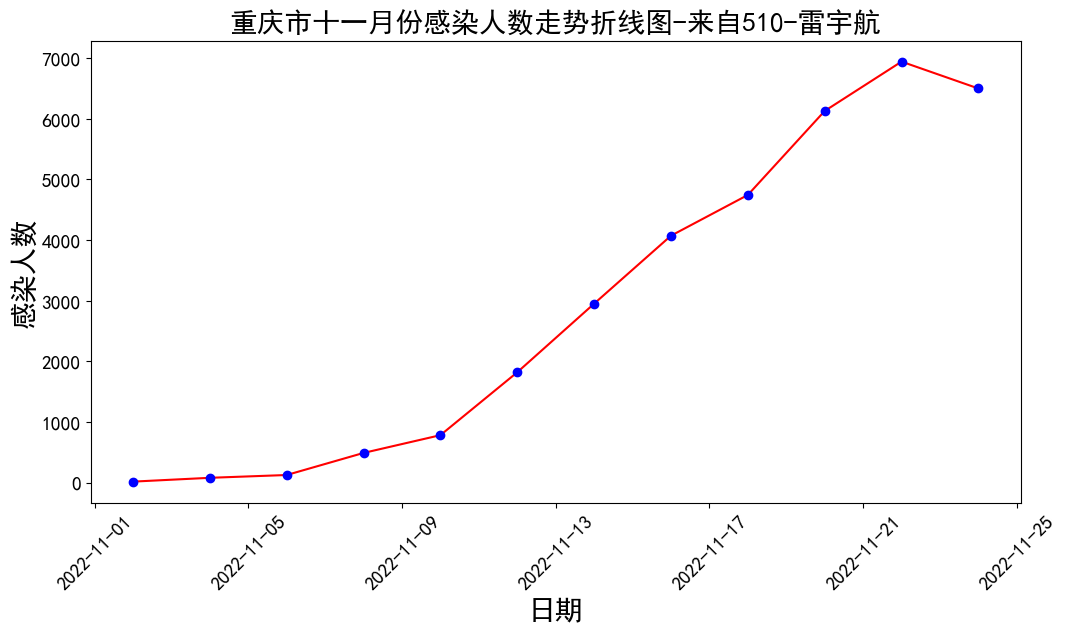

In [7]:
## 实例二
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel('cq_COVID-19.xlsx',sheet_name=None)#以读的方式打开文件
Df = df['sheet_COVID-19'].iloc[1:29:2][['日期','感染人数']]
rq = []
rs = []
rq = Df['日期'].tolist()
rs = Df['感染人数'].tolist()
plt.rcParams['font.family']='SimHei'#设置字体，为黑体
plt.figure(figsize=(12,6))#创建画板，并设置其大小
plt.tick_params(labelsize=14)#设置刻度线字号
plt.plot(rq,rs,'ro-',mec='b',mfc='b')
plt.title("重庆市十一月份感染人数走势折线图-来自510-雷宇航",fontsize=20)#设置图的标题
plt.ylabel("感染人数",fontsize=20)
plt.xlabel("日期",fontsize=20)
plt.xticks(rotation=45)
plt.savefig('结果图.covid.png',dpi=300, bbox_inches='tight')
plt.show()

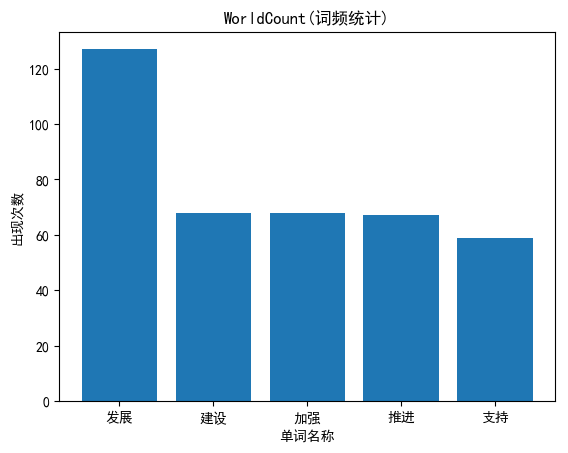

In [6]:
## 思考一
import jieba
import matplotlib.pyplot as plt
wf = 'govreport-2022.txt'#词源的文本文件
word_content = open(wf,'r',encoding='utf-8').read().replace('\n','')#读取文件内容
word_cut= jieba.cut(word_content)#进行分词操作
counts= {}
for word in word_cut:
    word = word.replace("，","").replace("！","").replace("“","")\
        .replace("”","").replace("。","").replace("？","")\
        .replace("：","").replace("...","").replace("、","").strip('')\
        .strip('\r\n')
    if len(word) ==1 or word == "":
        continue
    else:
        counts[word]=counts.get(word,0)+1
items= list(counts.items())#将字典转换为list
items.sort(key=lambda x:x[1],reverse=True)#降序排序
w=[]
c=[]
for i in range(5):
    word1,count = items[i]
    w.append(word1)
    c.append(count)
plt.rcParams['font.sans-serif']=['SimHei']#正常显示中文汉字
plt.bar(w,c)
plt.xlabel("单词名称")
plt.ylabel("出现次数")
plt.title("WorldCount(词频统计)")
plt.savefig('结果图.词频.png', dpi=300, bbox_inches='tight')
plt.show()